# Notebook 07 — Psychological Inference Layer (GSS → ACS)

This notebook enriches the structural population model derived from the **American Community Survey (ACS)** with **probabilistic psychological traits** estimated from the **General Social Survey (GSS)**.

Because ACS provides large-scale demographic structure but limited attitudinal information, GSS survey data are used to estimate how attitudes vary across demographic groups and then project those patterns onto the full ACS population.

---

## Methodological Workflow

### Phase 1 — GSS Data Preparation
Load the GSS survey dataset and select relevant demographic and attitudinal variables.  
Demographic variables are harmonized to match the structural feature space used in the ACS population model.

---

### Phase 2 — Psychological Feature Engineering
Survey responses are transformed into interpretable attitudinal traits, including:

- ideology  
- party alignment  
- religiosity  
- life satisfaction  
- media engagement

These variables form the **attitudinal target space** for inference.

---

### Phase 3 — Structural Cell Definition
Respondents are grouped into demographic cells defined by key structural attributes (age, sex, race/ethnicity, education).  
These cells represent the units used to estimate conditional attitude probabilities.

---

### Phase 4 — Survey-Weighted Probability Estimation
Within each structural cell, weighted probabilities for each attitudinal trait are computed using GSS survey weights, producing estimates of the form:

P(attitude | demographic structure)

---

### Phase 5 — Hierarchical Fallback Strategy
To address sparse survey cells, a hierarchical fallback procedure progressively relaxes the demographic schema until a stable estimate is available.

---

### Phase 6 — Projection onto the ACS Population
The estimated probability tables are applied to the ACS adult population dataset, assigning each individual a probability distribution across psychological traits.

---

### Phase 7 — Population-Level Validation
The synthetic population distributions are compared against the original weighted GSS benchmarks to confirm statistical consistency.

---

## Output

The notebook produces a population dataset combining:

- ACS structural features  
- structural cluster assignments  
- probabilistic psychological attributes

Saved as:

`mk_structural_attitudes_population_v1.parquet`

This dataset represents the **Psychological Inference Layer** of the Market Kinetics population model.

In [132]:
# ============================================================
# 0. Imports and path setup
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# project root
PROJECT_ROOT = Path.cwd().resolve().parents[0]

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR = DATA_DIR / "societal_raw"
PROCESSED_DIR = DATA_DIR / "societal_processed"
MODELS_DIR = DATA_DIR / "societal_models"

# notebook 06 output
ACS_CLUSTERED_PATH = MODELS_DIR / "mk_structural_population_clustered_v1.parquet"

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ACS clustered file exists:", ACS_CLUSTERED_PATH.exists())
print("ACS clustered path:", ACS_CLUSTERED_PATH)

PROJECT_ROOT: /Users/marcomagnolo/Projects/Market_Kinetics
ACS clustered file exists: True
ACS clustered path: /Users/marcomagnolo/Projects/Market_Kinetics/data/societal_models/mk_structural_population_clustered_v1.parquet


In [133]:
# GSS dataset is huge, so we filter on the relevant features first
gss_cols = [
    "year",
    "age",
    "sex",
    "race",
    "hispanic",
    "educ",
    "degree",
    "marital",
    "wrkstat",
    "realrinc",
    "wtssall",

    # attitudinal variables
    "polviews",
    "partyid",
    "trust",
    "helpful",
    "fair",
    "happy",
    "relig",
    "attend",
    "news"
]

In [134]:
# load subset of GSS
import pyreadstat

GSS_PATH = RAW_DIR / "GSS_spss" / "gss7224_r2.sav"

df_gss, meta = pyreadstat.read_sav(
    GSS_PATH,
    usecols=gss_cols,
    apply_value_formats=False
)

In [135]:
# filter on recent waves
df_gss = df_gss[df_gss["year"] >= 2018].copy()

print("Filtered dataset shape:", df_gss.shape)
print("Years included:", df_gss["year"].unique())

Filtered dataset shape: (13233, 20)
Years included: [2018. 2021. 2022. 2024.]


In [136]:
df_gss.head()

,year,wrkstat,marital,age,educ,degree,sex,race,partyid,polviews,relig,attend,happy,helpful,fair,trust,news,realrinc,hispanic,wtssall
62466,2018.0,3.0,5.0,43.0,14.0,2.0,1.0,1.0,5.0,6.0,11.0,5.0,2.0,NaN,NaN,NaN,4.0,NaN,1.0,2.357493
62467,2018.0,5.0,4.0,74.0,10.0,1.0,2.0,1.0,2.0,NaN,2.0,2.0,1.0,1.0,1.0,1.0,NaN,NaN,1.0,0.942997
62468,2018.0,1.0,1.0,42.0,16.0,3.0,1.0,1.0,4.0,5.0,4.0,2.0,1.0,1.0,2.0,2.0,5.0,45400.0,5.0,0.942997
62469,2018.0,1.0,1.0,63.0,16.0,3.0,2.0,1.0,2.0,4.0,1.0,6.0,1.0,1.0,2.0,1.0,1.0,54480.0,1.0,0.942997
62470,2018.0,5.0,3.0,71.0,18.0,4.0,1.0,2.0,6.0,7.0,2.0,8.0,2.0,1.0,2.0,1.0,NaN,NaN,1.0,0.942997


In [137]:
df_gss.info()

<class 'pandas.DataFrame'>
RangeIndex: 13233 entries, 62466 to 75698
Data columns (total 20 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   year      13233 non-null  float64
 1   wrkstat   13205 non-null  float64
 2   marital   13192 non-null  float64
 3   age       12584 non-null  float64
 4   educ      13121 non-null  float64
 5   degree    13207 non-null  float64
 6   sex       13102 non-null  float64
 7   race      13061 non-null  float64
 8   partyid   13092 non-null  float64
 9   polviews  12797 non-null  float64
 10  relig     13030 non-null  float64
 11  attend    13079 non-null  float64
 12  happy     13159 non-null  float64
 13  helpful   3705 non-null   float64
 14  fair      3696 non-null   float64
 15  trust     3721 non-null   float64
 16  news      8788 non-null   float64
 17  realrinc  7685 non-null   float64
 18  hispanic  13120 non-null  float64
 19  wtssall   2348 non-null   float64
dtypes: float64(20)
memory usage: 2.0 MB

In [138]:
# Missingness summary

missing_summary = pd.DataFrame({
    "non_null": df_gss.notna().sum(),
    "missing": df_gss.isna().sum(),
    "missing_pct": (df_gss.isna().mean() * 100).round(2)
}).sort_values("missing_pct")

display(missing_summary)

,non_null,missing,missing_pct
year,13233,0,0.00
degree,13207,26,0.20
wrkstat,13205,28,0.21
marital,13192,41,0.31
happy,13159,74,0.56
educ,13121,112,0.85
hispanic,13120,113,0.85
sex,13102,131,0.99
partyid,13092,141,1.07
attend,13079,154,1.16


## GSS Variable Definitions (Selected Fields)

The following variables were extracted from the General Social Survey (GSS) to support the psychological inference layer. Each variable is originally coded according to the GSS survey design and must be interpreted using its survey coding scheme.

### Structural Predictors

**year**  
Survey year in which the interview was conducted. Used to restrict analysis to recent waves (e.g., 2018–2024) to ensure that inferred psychological relationships reflect contemporary attitudes.

**wrkstat**  
Respondent’s employment status at the time of the survey. Typical coded categories include full-time employment, part-time employment, unemployed, retired, student, homemaker, or not in the labor force.

**marital**  
Current marital status of the respondent (e.g., married, widowed, divorced, separated, never married). This variable is used to construct the `mar_tier` structural feature aligned with the ACS schema.

**age**  
Age of the respondent in years. This variable will be converted into categorical age bins to match the ACS-derived `age_bin` feature used in the structural clustering layer.

**educ**  
Total years of formal education completed by the respondent. This is often used as a continuous proxy for educational attainment.

**degree**  
Highest educational degree obtained (e.g., high school diploma, associate degree, bachelor’s degree, graduate degree). This variable is generally more suitable than `educ` for constructing education tiers.

**sex**  
Respondent’s biological sex as recorded in the survey (typically coded as male or female).

**race**  
Self-identified race of the respondent. GSS race categories typically include White, Black, and Other race categories.

**hispanic**  
Indicator of Hispanic or Latino origin. This variable is combined with `race` to construct a `race_eth` variable compatible with ACS race/ethnicity categories.

**realrinc**  
Respondent’s real (inflation-adjusted) family income. This variable can be used to construct income tiers approximating ACS household income brackets.

**wtssall**  
Survey sampling weight provided by GSS. This weight adjusts for sampling design and non-response so that the survey sample better represents the U.S. population.

---

### Psychological / Attitudinal Variables

**partyid**  
Political party identification of the respondent. Categories typically range from strong Democrat to strong Republican, with independent categories in between.

**polviews**  
Self-reported political ideology. This variable measures ideological orientation along a liberal–conservative spectrum.

**relig**  
Religious affiliation of the respondent (e.g., Protestant, Catholic, Jewish, other religion, or none).

**attend**  
Frequency of religious service attendance. This variable measures the intensity of religious practice rather than affiliation alone.

**happy**  
Self-reported level of general happiness or life satisfaction.

**helpful**  
Agreement with the statement that people are generally helpful rather than selfish.

**fair**  
Agreement with the statement that people generally try to be fair rather than take advantage of others.

**trust**  
Generalized interpersonal trust (whether most people can be trusted or one cannot be too careful).

**news**  
Frequency with which the respondent follows the news. This variable serves as a proxy for political engagement and media consumption.

Summary statistics for numerical columns:


,year,wrkstat,marital,age,educ,degree,sex,race,partyid,polviews,relig,attend,happy,helpful,fair,trust,news,realrinc,hispanic,wtssall
count,13233.000000,13205.000000,13192.000000,12584.000000,13121.000000,13207.000000,13102.000000,13061.000000,13092.000000,12797.000000,13030.000000,13079.000000,13159.000000,3705.000000,3696.000000,3721.000000,8788.000000,7685.000000,13120.000000,2348.000000
mean,2021.485680,3.097690,2.644633,50.320804,14.268272,1.893541,1.551061,1.378455,2.891231,4.024459,2.629624,2.860310,1.986017,1.685290,1.639069,1.798441,3.554848,26514.504917,1.289329,1.000000
std,1.969683,2.304389,1.702096,17.786324,2.910500,1.269056,0.497405,0.679513,2.087738,1.526656,2.193365,2.756352,0.658605,0.668451,0.641488,0.560057,1.593866,28119.217269,0.867189,0.611458
min,2018.000000,1.000000,1.000000,18.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,181.500000,1.000000,0.471499
25%,2021.000000,1.000000,1.000000,35.000000,12.000000,1.000000,1.000000,1.000000,1.000000,3.000000,1.000000,0.000000,2.000000,1.000000,1.000000,1.000000,2.000000,9265.000000,1.000000,0.471499
50%,2022.000000,2.000000,2.000000,50.000000,14.000000,1.000000,2.000000,1.000000,3.000000,4.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,4.000000,19620.000000,1.000000,0.942997
75%,2024.000000,5.000000,5.000000,65.000000,16.000000,3.000000,2.000000,2.000000,5.000000,5.000000,4.000000,5.000000,2.000000,2.000000,2.000000,2.000000,5.000000,33742.500000,1.000000,0.942997
max,2024.000000,8.000000,5.000000,89.000000,20.000000,4.000000,2.000000,3.000000,7.000000,7.000000,13.000000,8.000000,3.000000,3.000000,3.000000,3.000000,5.000000,151050.721360,5.000000,5.897420



Value counts for sex:


sex
2.0    7220
1.0    5882
NaN     131
Name: count, dtype: int64


Value counts for race:


...

trust
NaN    9512
2.0    2403
1.0    1034
3.0     284
Name: count, dtype: int64


Value counts for news:


news
NaN    4445
5.0    3998
1.0    1679
4.0    1279
2.0    1041
3.0     791
Name: count, dtype: int64


Correlation matrix for numerical columns:


,age,educ,realrinc
age,1.000000,0.021705,0.137889
educ,0.021705,1.000000,0.320459
realrinc,0.137889,0.320459,1.000000


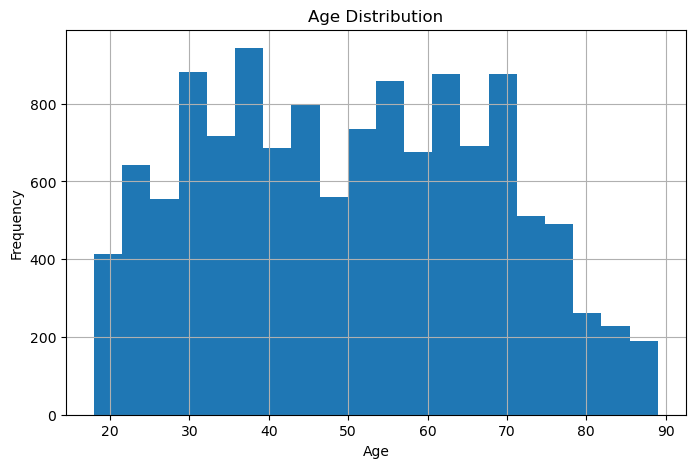

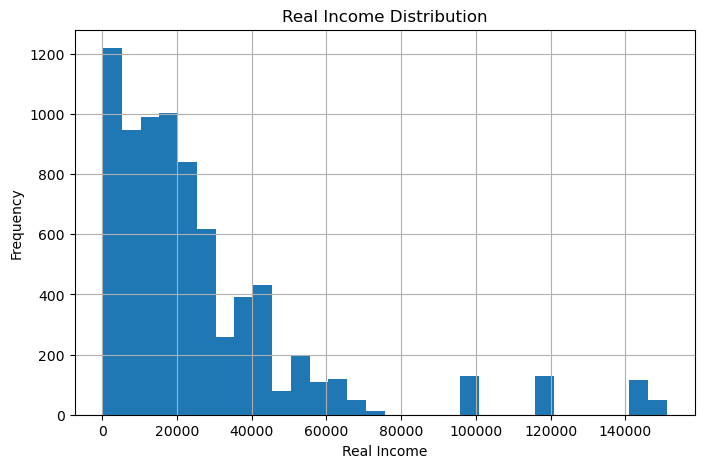


Cross-tabulation: Sex vs. Political Views


polviews,1.0,2.0,3.0,4.0,5.0,6.0,7.0
sex,,,,,,,
1.0,0.049355,0.127136,0.118765,0.338158,0.141611,0.173526,0.051448
2.0,0.053607,0.153780,0.118281,0.379419,0.107646,0.142139,0.045128


In [139]:
# ============================================================
# Exploratory Data Analysis (EDA) on df_gss
# ============================================================

# Basic summary statistics for numerical columns
print("Summary statistics for numerical columns:")
display(df_gss.describe())

# Value counts for categorical/ordinal columns
categorical_cols = ['sex', 'race', 'hispanic', 'marital', 'wrkstat', 'degree', 'partyid', 'polviews', 'relig', 'attend', 'happy', 'helpful', 'fair', 'trust', 'news']

for col in categorical_cols:
    print(f"\nValue counts for {col}:")
    display(df_gss[col].value_counts(dropna=False).head(10))  # Show top 10 for brevity

# Check for correlations between numerical variables
numerical_cols = ['age', 'educ', 'realrinc']
print("\nCorrelation matrix for numerical columns:")
display(df_gss[numerical_cols].corr())

# Distribution of age
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
df_gss['age'].dropna().hist(bins=20)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Distribution of realrinc (income)
plt.figure(figsize=(8, 5))
df_gss['realrinc'].dropna().hist(bins=30)
plt.title('Real Income Distribution')
plt.xlabel('Real Income')
plt.ylabel('Frequency')
plt.show()

# Cross-tabulation: sex vs. polviews
print("\nCross-tabulation: Sex vs. Political Views")
display(pd.crosstab(df_gss['sex'], df_gss['polviews'], normalize='index'))



## GSS Coding Reference for Selected Variables

The variables loaded for this notebook are coded survey fields from the General Social Survey (GSS). Before harmonizing them to the ACS structural schema, their original numeric meanings should be documented clearly.

### Structural Variables

**year**  
Survey year.
- 2018 = 2018 wave
- 2021 = 2021 wave
- 2022 = 2022 wave
- 2024 = 2024 wave  
Used to restrict the analysis to recent waves.

**wrkstat** — Labor force / work status
- 1 = Working full time
- 2 = Working part time
- 3 = Temporarily not working
- 4 = Unemployed, laid off
- 5 = Retired
- 6 = School
- 7 = Keeping house
- 8 = Other

**marital** — Marital status
- 1 = Married
- 2 = Widowed
- 3 = Divorced
- 4 = Separated
- 5 = Never married

**age**  
Respondent age in years.

**educ**  
Years of formal schooling completed.

**degree** — Highest degree earned
- 0 = Less than high school
- 1 = High school
- 2 = Junior college / associate
- 3 = Bachelor
- 4 = Graduate

**sex**
- 1 = Male
- 2 = Female

**race**
- 1 = White
- 2 = Black
- 3 = Other

**hispanic** — Hispanic origin
- 1 = Not Hispanic
- 2 = Mexican
- 3 = Puerto Rican
- 4 = Cuban
- 5 = Other Spanish / Hispanic
- Additional codes may appear depending on wave-specific processing  
For harmonization purposes, any non-1 valid code will typically be treated as Hispanic.

**realrinc**  
Real income measure provided by GSS, adjusted for inflation.  
Used here as the closest available income proxy for ACS income tier harmonization.

**wtssall**  
GSS survey weight for combined samples.  
Used when appropriate to produce weighted descriptive summaries.

---

### Psychological / Attitudinal Variables

**partyid** — Party identification
- 0 = Strong Democrat
- 1 = Not strong Democrat
- 2 = Independent, near Democrat
- 3 = Independent
- 4 = Independent, near Republican
- 5 = Not strong Republican
- 6 = Strong Republican
- 7 = Other party

**polviews** — Political ideology
- 1 = Extremely liberal
- 2 = Liberal
- 3 = Slightly liberal
- 4 = Moderate
- 5 = Slightly conservative
- 6 = Conservative
- 7 = Extremely conservative

**relig** — Religious preference
- 1 = Protestant
- 2 = Catholic
- 3 = Jewish
- 4 = None
- 5 = Other
- 6 = Buddhist
- 7 = Hindu
- 8 = Other Eastern
- 9 = Muslim / Islam
- 10 = Orthodox-Christian
- 11 = Christian
- 12 = Native American
- 13 = Inter-/nondenominational

**attend** — Frequency of religious service attendance
- 0 = Never
- 1 = Less than once a year
- 2 = About once or twice a year
- 3 = Several times a year
- 4 = About once a month
- 5 = 2–3 times a month
- 6 = Nearly every week
- 7 = Every week
- 8 = More than once a week

**happy** — General happiness
- 1 = Very happy
- 2 = Pretty happy
- 3 = Not too happy

**helpful** — View of others as helpful vs selfish
- 1 = People try to be helpful
- 2 = People mostly look out for themselves
- 3 = Depends

**fair** — View of others as fair vs exploitative
- 1 = People try to be fair
- 2 = People would try to take advantage
- 3 = Depends

**trust** — Generalized interpersonal trust
- 1 = Most people can be trusted
- 2 = Cannot be too careful
- 3 = Depends

**news** — Frequency of following the news
- 1 = Every day
- 2 = A few times a week
- 3 = Once a week
- 4 = Less than once a week
- 5 = Never

---

### Notes for Modeling

Several GSS variables are ordinal rather than purely nominal. For example:
- `polviews`
- `partyid`
- `attend`
- `happy`
- `news`

These variables should be treated carefully during modeling and may later be collapsed into broader categories if needed for stability and interpretability.

In the next step, the structural variables will be recoded into ACS-aligned categories so that GSS-based psychological models can be applied to the clustered ACS population dataset.

In [140]:
# Harmonize basic GSS structural variables to ACS schema

df_gss_model = df_gss.copy()

# age_bin
def map_age_bin(age):
    if pd.isna(age):
        return np.nan
    age = float(age)
    if age < 18:
        return "Under_18"
    elif age <= 24:
        return "18_24"
    elif age <= 34:
        return "25_34"
    elif age <= 44:
        return "35_44"
    elif age <= 54:
        return "45_54"
    elif age <= 64:
        return "55_64"
    else:
        return "65_plus"

df_gss_model["age_bin"] = df_gss_model["age"].apply(map_age_bin)

# sex_label
sex_map = {
    1.0: "Male",
    2.0: "Female"
}
df_gss_model["sex_label"] = df_gss_model["sex"].map(sex_map)

# mar_tier
marital_map = {
    1.0: "Married",
    2.0: "Widowed",
    3.0: "Divorced",
    4.0: "Separated",
    5.0: "Never_Married"
}
df_gss_model["mar_tier"] = df_gss_model["marital"].map(marital_map)

display(
    df_gss_model[
        ["age", "age_bin", "sex", "sex_label", "marital", "mar_tier"]
    ].head(10)
)

,age,age_bin,sex,sex_label,marital,mar_tier
62466,43.0,35_44,1.0,Male,5.0,Never_Married
62467,74.0,65_plus,2.0,Female,4.0,Separated
62468,42.0,35_44,1.0,Male,1.0,Married
62469,63.0,55_64,2.0,Female,1.0,Married
62470,71.0,65_plus,1.0,Male,3.0,Divorced
62471,67.0,65_plus,2.0,Female,2.0,Widowed
62472,59.0,55_64,2.0,Female,3.0,Divorced
62473,43.0,35_44,1.0,Male,5.0,Never_Married
62474,62.0,55_64,2.0,Female,2.0,Widowed
62475,55.0,55_64,1.0,Male,1.0,Married


In [141]:
# validation
for col in ["age_bin", "sex_label", "mar_tier"]:
    print(f"\n{col}")
    print(df_gss_model[col].value_counts(dropna=False))


age_bin
age_bin
65_plus    3247
35_44      2238
55_64      2223
25_34      2121
45_54      1876
18_24       879
NaN         649
Name: count, dtype: int64

sex_label
sex_label
Female    7220
Male      5882
NaN        131
Name: count, dtype: int64

mar_tier
mar_tier
Married          5828
Never_Married    3796
Divorced         2182
Widowed          1005
Separated         381
NaN                41
Name: count, dtype: int64


In [142]:
# Check race_eth categories in the ACS clustered dataset
df_acs = pd.read_parquet("/Users/marcomagnolo/Projects/Market_Kinetics/data/societal_models/mk_structural_population_clustered_v1.parquet")

print("Shape:", df_acs.shape)
print("\nColumns:")
print(df_acs.columns.tolist())

print("\nRace/Ethnicity distribution:")
print(df_acs["race_eth"].value_counts(dropna=False))

print("\nRace/Ethnicity share:")
print((df_acs["race_eth"].value_counts(normalize=True) * 100).round(2))

Shape: (1000000, 18)

Columns:
['serialno', 'sporder', 'pwgtp', 'age_bin', 'sex_label', 'race_eth', 'edu_tier', 'emp_tier', 'income_tier_fixed', 'mar_tier', 'commute_tier', 'tenure', 'household_size', 'vehicle_count', 'puma', 'hhincome_tier', 'household_type', 'cluster']

Race/Ethnicity distribution:
race_eth
White_NH    581750
Hispanic    189931
Black_NH    120245
Asian_NH     57479
Other_NH     50595
Name: count, dtype: int64[pyarrow]

Race/Ethnicity share:
race_eth
White_NH    58.18
Hispanic    18.99
Black_NH    12.02
Asian_NH     5.75
Other_NH     5.06
Name: proportion, dtype: double[pyarrow]


In [143]:
# race_eth harmonization


def map_race_eth(row):

    race = row["race"]
    hisp = row["hispanic"]

    if pd.isna(race):
        return np.nan

    # Hispanic origin overrides race
    if pd.notna(hisp) and hisp != 1:
        return "Hispanic"

    if race == 1:
        return "White_NH"

    if race == 2:
        return "Black_NH"

    return "Other_NH"


df_gss_model["race_eth"] = df_gss_model.apply(map_race_eth, axis=1)

print(df_gss_model["race_eth"].value_counts(dropna=False))

race_eth
White_NH    8635
Black_NH    1868
Hispanic    1781
Other_NH     777
NaN          172
Name: count, dtype: int64


In [144]:
df_gss_model.head()

,year,wrkstat,marital,age,educ,degree,sex,race,partyid,polviews,...,fair,trust,news,realrinc,hispanic,wtssall,age_bin,sex_label,mar_tier,race_eth
62466,2018.0,3.0,5.0,43.0,14.0,2.0,1.0,1.0,5.0,6.0,...,NaN,NaN,4.0,NaN,1.0,2.357493,35_44,Male,Never_Married,White_NH
62467,2018.0,5.0,4.0,74.0,10.0,1.0,2.0,1.0,2.0,NaN,...,1.0,1.0,NaN,NaN,1.0,0.942997,65_plus,Female,Separated,White_NH
62468,2018.0,1.0,1.0,42.0,16.0,3.0,1.0,1.0,4.0,5.0,...,2.0,2.0,5.0,45400.0,5.0,0.942997,35_44,Male,Married,Hispanic
62469,2018.0,1.0,1.0,63.0,16.0,3.0,2.0,1.0,2.0,4.0,...,2.0,1.0,1.0,54480.0,1.0,0.942997,55_64,Female,Married,White_NH
62470,2018.0,5.0,3.0,71.0,18.0,4.0,1.0,2.0,6.0,7.0,...,2.0,1.0,NaN,NaN,1.0,0.942997,65_plus,Male,Divorced,Black_NH


In [145]:
df_acs['edu_tier'].value_counts()

edu_tier
HS_or_less      483884
Some_college    231203
Bachelor        156864
Graduate         95040
Missing          33009
Name: count, dtype: int64[pyarrow]

In [146]:
df_gss['degree'].value_counts()

degree
1.0    5935
3.0    2959
4.0    1958
2.0    1182
0.0    1173
Name: count, dtype: int64

In [147]:
# Harmonize education to ACS schema


degree_map = {
    0: "HS_or_less",      # less than high school
    1: "HS_or_less",      # high school
    2: "Some_college",    # junior college / associate
    3: "Bachelor",        # bachelor degree
    4: "Graduate"         # graduate degree
}

df_gss_model["edu_tier"] = df_gss_model["degree"].map(degree_map)

print(df_gss_model["edu_tier"].value_counts(dropna=False))

edu_tier
HS_or_less      7108
Bachelor        2959
Graduate        1958
Some_college    1182
NaN               26
Name: count, dtype: int64


In [148]:
# Harmonize employment status

def map_emp_tier(x):

    if pd.isna(x):
        return np.nan

    if x in [1, 2]:
        return "Employed"

    if x in [3, 4]:
        return "Unemployed"

    if x in [5, 6, 7, 8]:
        return "Not_in_labor_force"

    return np.nan


df_gss_model["emp_tier"] = df_gss_model["wrkstat"].apply(map_emp_tier)

print(df_gss_model["emp_tier"].value_counts(dropna=False))

emp_tier
Employed              7259
Not_in_labor_force    4937
Unemployed            1009
NaN                     28
Name: count, dtype: int64


In [149]:
# Harmonize income to ACS income_tier_fixed schema

def map_income_tier(x):

    if pd.isna(x):
        return "Missing"

    if x <= 0:
        return "<=0"

    if x < 20000:
        return "0-19k"

    if x < 50000:
        return "20-49k"

    if x < 100000:
        return "50-99k"

    if x < 200000:
        return "100-199k"

    return "200k+"


df_gss_model["income_tier_fixed"] = df_gss_model["realrinc"].apply(map_income_tier)

print(df_gss_model["income_tier_fixed"].value_counts(dropna=False))

income_tier_fixed
Missing     5548
0-19k       4161
20-49k      2619
50-99k       613
100-199k     292
Name: count, dtype: int64


## Structural Harmonization Check: ACS vs GSS

Before training attitudinal inference models, the structural variables derived from the GSS dataset must match the schema used in the ACS structural population dataset.

This section compares the two datasets to verify:

- identical variable names
- identical category labels
- no unexpected categories

The objective is not to match distributions exactly, but to ensure that the feature space used to train models on GSS can be safely applied to the ACS clustered population dataset.

In [150]:
# ============================================================
# Structural schema comparison: ACS vs GSS
# ============================================================

struct_cols = [
    "age_bin",
    "sex_label",
    "race_eth",
    "mar_tier",
    "edu_tier",
    "emp_tier",
    "income_tier_fixed"
]

print("Checking structural columns...\n")

for col in struct_cols:

    print("================================================")
    print(f"VARIABLE: {col}")
    print("================================================")

    acs_vals = sorted(df_acs[col].dropna().unique())
    gss_vals = sorted(df_gss_model[col].dropna().unique())

    print("\nACS categories:")
    print(acs_vals)

    print("\nGSS categories:")
    print(gss_vals)

    acs_set = set(acs_vals)
    gss_set = set(gss_vals)

    print("\nCategories only in ACS:")
    print(sorted(acs_set - gss_set))

    print("\nCategories only in GSS:")
    print(sorted(gss_set - acs_set))

    print("\n")

Checking structural columns...

VARIABLE: age_bin

ACS categories:
['0-5', '13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '6-12', '65+']

GSS categories:
['18_24', '25_34', '35_44', '45_54', '55_64', '65_plus']

Categories only in ACS:
['0-5', '13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '6-12', '65+']

Categories only in GSS:
['18_24', '25_34', '35_44', '45_54', '55_64', '65_plus']


VARIABLE: sex_label

ACS categories:
['Female', 'Male']

GSS categories:
['Female', 'Male']

Categories only in ACS:
[]

Categories only in GSS:
[]


VARIABLE: race_eth

ACS categories:
['Asian_NH', 'Black_NH', 'Hispanic', 'Other_NH', 'White_NH']

GSS categories:
['Black_NH', 'Hispanic', 'Other_NH', 'White_NH']

Categories only in ACS:
['Asian_NH']

Categories only in GSS:
[]


VARIABLE: mar_tier

ACS categories:
['Married', 'Never_Married', 'Previously_Married']

GSS categories:
['Divorced', 'Married', 'Never_Married', 'Separated', 'Widowed']

Categories only in ACS:
['Previously_Married'

In [151]:
age_map = {
    "18_24": "18-24",
    "25_34": "25-34",
    "35_44": "35-44",
    "45_54": "45-54",
    "55_64": "55-64",
    "65_plus": "65+"
}

df_gss_model["age_bin"] = df_gss_model["age_bin"].map(age_map)

In [152]:
mar_map = {
    "Married": "Married",
    "Never_Married": "Never_Married",
    "Divorced": "Previously_Married",
    "Separated": "Previously_Married",
    "Widowed": "Previously_Married"
}

df_gss_model["mar_tier"] = df_gss_model["mar_tier"].map(mar_map)

In [153]:
df_gss_model["edu_tier"] = df_gss_model["edu_tier"].fillna("Missing")

In [154]:
def map_emp_tier(x):

    if pd.isna(x):
        return "Missing"

    if x in [1,2]:
        return "Employed"

    if x in [3,4]:
        return "Unemployed"

    if x == 5:
        return "Retired"

    if x == 6:
        return "Student"

    if x in [7,8]:
        return "Other_Not_in_Labor_Force"

df_gss_model["emp_tier"] = df_gss["wrkstat"].apply(map_emp_tier)

In [155]:
# ============================================================
# Structural schema comparison: ACS vs GSS
# ============================================================

struct_cols = [
    "age_bin",
    "sex_label",
    "race_eth",
    "mar_tier",
    "edu_tier",
    "emp_tier",
    "income_tier_fixed"
]

print("Checking structural columns...\n")

for col in struct_cols:

    print("================================================")
    print(f"VARIABLE: {col}")
    print("================================================")

    acs_vals = sorted(df_acs[col].dropna().unique())
    gss_vals = sorted(df_gss_model[col].dropna().unique())

    print("\nACS categories:")
    print(acs_vals)

    print("\nGSS categories:")
    print(gss_vals)

    acs_set = set(acs_vals)
    gss_set = set(gss_vals)

    print("\nCategories only in ACS:")
    print(sorted(acs_set - gss_set))

    print("\nCategories only in GSS:")
    print(sorted(gss_set - acs_set))

    print("\n")

Checking structural columns...

VARIABLE: age_bin

ACS categories:
['0-5', '13-17', '18-24', '25-34', '35-44', '45-54', '55-64', '6-12', '65+']

GSS categories:
['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

Categories only in ACS:
['0-5', '13-17', '6-12']

Categories only in GSS:
[]


VARIABLE: sex_label

ACS categories:
['Female', 'Male']

GSS categories:
['Female', 'Male']

Categories only in ACS:
[]

Categories only in GSS:
[]


VARIABLE: race_eth

ACS categories:
['Asian_NH', 'Black_NH', 'Hispanic', 'Other_NH', 'White_NH']

GSS categories:
['Black_NH', 'Hispanic', 'Other_NH', 'White_NH']

Categories only in ACS:
['Asian_NH']

Categories only in GSS:
[]


VARIABLE: mar_tier

ACS categories:
['Married', 'Never_Married', 'Previously_Married']

GSS categories:
['Married', 'Never_Married', 'Previously_Married']

Categories only in ACS:
[]

Categories only in GSS:
[]


VARIABLE: edu_tier

ACS categories:
['Bachelor', 'Graduate', 'HS_or_less', 'Missing', 'Some_college']

GSS categ

In [156]:

# Inspect psychological variables


attitude_cols = [
    "partyid",
    "polviews",
    "relig",
    "attend",
    "happy",
    "news",
    "trust",
    "fair",
    "helpful"
]

for col in attitude_cols:

    print("\n====================")
    print(col)
    print("====================")

    print("Non-null:", df_gss_model[col].notna().sum())
    print(df_gss_model[col].value_counts(dropna=False))


partyid
Non-null: 13092
partyid
3.0    2895
0.0    2328
1.0    1716
6.0    1670
2.0    1518
5.0    1395
4.0    1190
7.0     380
NaN     141
Name: count, dtype: int64

polviews
Non-null: 12797
polviews
4.0    4625
6.0    2001
2.0    1808
5.0    1570
3.0    1514
1.0     661
7.0     618
NaN     436
Name: count, dtype: int64

relig
Non-null: 13030
relig
1.0     5552
4.0     3516
2.0     2710
11.0     309
5.0      253
3.0      222
NaN      203
6.0      120
9.0      105
7.0       97
10.0      95
13.0      32
8.0       10
12.0       9
Name: count, dtype: int64

attend
Non-null: 13079
attend
0.0    4071
7.0    1810
2.0    1588
1.0    1474
3.0    1341
6.0     800
5.0     795
8.0     623
4.0     577
NaN     154
Name: count, dtype: int64

happy
Non-null: 13159
happy
2.0    7449
1.0    2947
3.0    2763
NaN      74
Name: count, dtype: int64

news
Non-null: 8788
news
NaN    4445
5.0    3998
1.0    1679
4.0    1279
2.0    1041
3.0     791
Name: count, dtype: int64

trust
Non-null: 3721
trust
NaN    

In [157]:
# checking the GSS codes in attitude variables
for col in attitude_cols:
    
    print("\n", col)
    print(sorted(df_gss_model[col].dropna().unique()))


 partyid
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]

 polviews
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0)]

 relig
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0), np.float64(12.0), np.float64(13.0)]

 attend
[np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0)]

 happy
[np.float64(1.0), np.float64(2.0), np.float64(3.0)]

 news
[np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]

 trust
[np.float64(1.0), np.float64(2.0), np.float64(3.0)]

 fair
[np.float64(1.0), np.float64(2.0), np.float64(3.0)]

 helpful
[np.float64(1.0), np.float64(2.0), np.float

## Phase 3 — Attitudinal Trait Construction

The raw GSS survey variables measure attitudes using detailed ordinal scales.  
For the purpose of psychological inference and segment interpretation, these scales are collapsed into interpretable behavioral traits.

This transformation improves:

- model stability
- interpretability of segment profiles
- downstream persona generation

The following derived psychological traits are constructed.

### Ideology (from `polviews`)

| polviews | Trait |
|---|---|
1–3 | Liberal |
4 | Moderate |
5–7 | Conservative |

### Party Alignment (from `partyid`)

| partyid | Trait |
|---|---|
0–2 | Democrat |
3 | Independent |
4–6 | Republican |
7 | Other |

### Religiosity (from `relig` + `attend`)

Religiosity captures both **religious affiliation** and **practice intensity**.

| Condition | Trait |
|---|---|
relig = 4 | None |
attend ≥ 6 | High |
attend 3–5 | Medium |
attend ≤ 2 | Low |

### Life Satisfaction (from `happy`)

| happy | Trait |
|---|---|
1 | Very happy |
2 | Pretty happy |
3 | Not happy |

### Media Engagement (from `news`)

| news | Trait |
|---|---|
1–2 | High |
3 | Medium |
4–5 | Low |

In [158]:
# Ideology


def map_ideology(x):

    if pd.isna(x):
        return np.nan

    if x <= 3:
        return "Liberal"

    if x == 4:
        return "Moderate"

    if x >= 5:
        return "Conservative"


df_gss_model["ideology"] = df_gss_model["polviews"].apply(map_ideology)

print(df_gss_model["ideology"].value_counts(dropna=False))

ideology
Moderate        4625
Conservative    4189
Liberal         3983
NaN              436
Name: count, dtype: int64


In [159]:
# Party Alignment


def map_party(x):

    if pd.isna(x):
        return np.nan

    if x <= 2:
        return "Democrat"

    if x == 3:
        return "Independent"

    if x <= 6:
        return "Republican"

    if x == 7:
        return "Other"


df_gss_model["party_alignment"] = df_gss_model["partyid"].apply(map_party)

print(df_gss_model["party_alignment"].value_counts(dropna=False))

party_alignment
Democrat       5562
Republican     4255
Independent    2895
Other           380
NaN             141
Name: count, dtype: int64


In [160]:
# Religiosity


def map_religiosity(row):

    relig = row["relig"]
    attend = row["attend"]

    if pd.isna(relig):
        return np.nan

    if relig == 4:
        return "None"

    if pd.isna(attend):
        return "Low"

    if attend >= 6:
        return "High"

    if attend >= 3:
        return "Medium"

    return "Low"


df_gss_model["religiosity"] = df_gss_model.apply(map_religiosity, axis=1)

print(df_gss_model["religiosity"].value_counts(dropna=False))

religiosity
Low       3935
None      3516
High      3076
Medium    2503
NaN        203
Name: count, dtype: int64


In [161]:
# Life Satisfaction


life_map = {
    1: "Very_happy",
    2: "Pretty_happy",
    3: "Not_happy"
}

df_gss_model["life_satisfaction"] = df_gss_model["happy"].map(life_map)

print(df_gss_model["life_satisfaction"].value_counts(dropna=False))

life_satisfaction
Pretty_happy    7449
Very_happy      2947
Not_happy       2763
NaN               74
Name: count, dtype: int64


In [162]:
# Media Engagement


def map_media(x):

    if pd.isna(x):
        return np.nan

    if x <= 2:
        return "High"

    if x == 3:
        return "Medium"

    return "Low"


df_gss_model["media_engagement"] = df_gss_model["news"].apply(map_media)

print(df_gss_model["media_engagement"].value_counts(dropna=False))

media_engagement
Low       5277
NaN       4445
High      2720
Medium     791
Name: count, dtype: int64


## Structural Cell Design

To estimate attitudinal trait distributions from GSS and project them onto the ACS structural population, a shared structural cell schema must be defined.

The goal is to balance two competing requirements:

- cells should be detailed enough to preserve meaningful demographic structure
- cells should be broad enough to retain sufficient GSS sample support

The next step evaluates several candidate cell schemas with increasing granularity in order to identify a stable post-stratification design.

In [163]:
# ============================================================
# Level 1 structural cell schema
# ============================================================

cell_vars_l1 = [
    "age_bin",
    "sex_label",
    "race_eth",
    "edu_tier"
]

print("Level 1 cell variables:", cell_vars_l1)

Level 1 cell variables: ['age_bin', 'sex_label', 'race_eth', 'edu_tier']


In [164]:
# ============================================================
# Raw GSS counts per Level 1 cell
# ============================================================

gss_cell_counts_l1 = (
    df_gss_model
    .groupby(cell_vars_l1)
    .size()
    .reset_index(name="n_gss")
    .sort_values("n_gss", ascending=False)
)

print("Number of Level-1 cells:", len(gss_cell_counts_l1))
display(gss_cell_counts_l1.head(20))

Number of Level-1 cells: 199


,age_bin,sex_label,race_eth,edu_tier,n_gss
180,65+,Female,White_NH,HS_or_less,740
197,65+,Male,White_NH,HS_or_less,617
147,55-64,Female,White_NH,HS_or_less,446
163,55-64,Male,White_NH,HS_or_less,349
195,65+,Male,White_NH,Bachelor,293
113,45-54,Female,White_NH,HS_or_less,283
178,65+,Female,White_NH,Bachelor,277
96,35-44,Male,White_NH,HS_or_less,276
79,35-44,Female,White_NH,HS_or_less,275
62,25-34,Male,White_NH,HS_or_less,272


In [165]:
# ============================================================
# Cell size distribution
# ============================================================

gss_cell_counts_l1["n_gss"].describe()

count    199.000000
mean      62.366834
std       98.924168
min        1.000000
25%       10.000000
50%       22.000000
75%       81.000000
max      740.000000
Name: n_gss, dtype: float64

In [166]:
gss_cell_counts_l1["n_gss"].value_counts().sort_index()

n_gss
1      11
2      11
3       2
4       3
6       3
       ..
293     1
349     1
446     1
617     1
740     1
Name: count, Length: 87, dtype: int64

In [167]:
# ============================================================
# Sparsity diagnostics
# ============================================================

total_cells = len(gss_cell_counts_l1)

cells_lt5 = (gss_cell_counts_l1["n_gss"] < 5).sum()
cells_lt10 = (gss_cell_counts_l1["n_gss"] < 10).sum()

print("Total cells:", total_cells)
print("Cells with <5 respondents:", cells_lt5)
print("Cells with <10 respondents:", cells_lt10)

print("\nPercent sparse (<10):", round(cells_lt10 / total_cells * 100, 2), "%")

Total cells: 199
Cells with <5 respondents: 27
Cells with <10 respondents: 49

Percent sparse (<10): 24.62 %


In [168]:
# ============================================================
# Weighted counts per cell
# ============================================================

gss_cell_weight_l1 = (
    df_gss_model
    .groupby(cell_vars_l1)["wtssall"]
    .sum()
    .reset_index(name="weighted_n")
    .sort_values("weighted_n", ascending=False)
)

display(gss_cell_weight_l1.head(20))

,age_bin,sex_label,race_eth,edu_tier,weighted_n
180,65+,Female,White_NH,HS_or_less,100.791857
197,65+,Male,White_NH,HS_or_less,98.077600
29,18-24,Male,White_NH,HS_or_less,78.044075
163,55-64,Male,White_NH,HS_or_less,74.975646
147,55-64,Female,White_NH,HS_or_less,70.500098
113,45-54,Female,White_NH,HS_or_less,68.614104
46,25-34,Female,White_NH,HS_or_less,64.837690
62,25-34,Male,White_NH,HS_or_less,60.592727
96,35-44,Male,White_NH,HS_or_less,60.360666
13,18-24,Female,White_NH,HS_or_less,56.346290


In [169]:
# ============================================================
# ACS cells
# ============================================================

acs_cells_l1 = (
    df_acs
    .groupby(cell_vars_l1)
    .size()
    .reset_index(name="n_acs")
)

print("ACS Level-1 cells:", len(acs_cells_l1))
display(acs_cells_l1.head())

ACS Level-1 cells: 290


,age_bin,sex_label,race_eth,edu_tier,n_acs
0,0-5,Female,Asian_NH,HS_or_less,869
1,0-5,Female,Asian_NH,Missing,784
2,0-5,Female,Black_NH,HS_or_less,2267
3,0-5,Female,Black_NH,Missing,2044
4,0-5,Female,Hispanic,HS_or_less,4555


In [170]:
# ============================================================
# Overlap diagnostics
# ============================================================

cell_overlap_l1 = acs_cells_l1.merge(
    gss_cell_counts_l1,
    on=cell_vars_l1,
    how="left"
)

missing_cells = cell_overlap_l1["n_gss"].isna().sum()

print("ACS cells not present in GSS:", missing_cells)

ACS cells not present in GSS: 100


## Hierarchical Fallback Strategy

Attitudinal probabilities are first estimated from the most specific shared structural cell available in GSS. When a cell has insufficient sample support, probabilities are assigned from progressively broader parent cells.

This hierarchical fallback approach preserves demographic structure where possible while reducing instability from sparse survey cells. Each ACS row will therefore receive probabilities from the most detailed reliable GSS cell available, with the source level retained for quality tracking.

In [171]:
# ============================================================
# Restrict ACS to adults only
# ============================================================

adult_age_bins = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

df_acs_adult = df_acs[df_acs["age_bin"].isin(adult_age_bins)].copy()

print("ACS adult shape:", df_acs_adult.shape)
print(df_acs_adult["age_bin"].value_counts(dropna=False))

ACS adult shape: (778466, 18)
age_bin
65+      168362
25-34    136702
35-44    131023
55-64    128245
45-54    122873
18-24     91261
Name: count, dtype: int64[pyarrow]


In [172]:
# ============================================================
# ACS adult Level-1 cells
# ============================================================

acs_cells_l1_adult = (
    df_acs_adult
    .groupby(cell_vars_l1)
    .size()
    .reset_index(name="n_acs")
)

print("ACS adult Level-1 cells:", len(acs_cells_l1_adult))
display(acs_cells_l1_adult.head())

ACS adult Level-1 cells: 240


,age_bin,sex_label,race_eth,edu_tier,n_acs
0,18-24,Female,Asian_NH,Bachelor,609
1,18-24,Female,Asian_NH,Graduate,81
2,18-24,Female,Asian_NH,HS_or_less,696
3,18-24,Female,Asian_NH,Some_college,1066
4,18-24,Female,Black_NH,Bachelor,561


In [173]:
# ============================================================
# Adult ACS ↔ GSS overlap
# ============================================================

cell_overlap_l1_adult = acs_cells_l1_adult.merge(
    gss_cell_counts_l1,
    on=cell_vars_l1,
    how="left"
)

missing_cells_adult = cell_overlap_l1_adult["n_gss"].isna().sum()

print("Adult ACS cells not present in GSS:", missing_cells_adult)

Adult ACS cells not present in GSS: 50


In [174]:
# ============================================================
# Hierarchical fallback schemas
# ============================================================

fallback_schemas = [
    ["age_bin", "sex_label", "race_eth", "edu_tier"],  # full Level-1
    ["age_bin", "race_eth", "edu_tier"],               # drop sex
    ["age_bin", "sex_label", "race_eth"],              # drop edu
    ["sex_label", "race_eth", "edu_tier"],             # drop age
    ["race_eth", "edu_tier"],                          # broader subgroup
    ["race_eth"]                                       # broadest subgroup
]

min_cell_n = 10

for i, schema in enumerate(fallback_schemas, start=1):
    print(f"Level {i}: {schema}")
print("Minimum raw GSS count:", min_cell_n)

Level 1: ['age_bin', 'sex_label', 'race_eth', 'edu_tier']
Level 2: ['age_bin', 'race_eth', 'edu_tier']
Level 3: ['age_bin', 'sex_label', 'race_eth']
Level 4: ['sex_label', 'race_eth', 'edu_tier']
Level 5: ['race_eth', 'edu_tier']
Level 6: ['race_eth']
Minimum raw GSS count: 10


In [175]:
# ============================================================
# Build weighted probability lookup table
# ============================================================

def build_probability_lookup(df, target_col, group_cols, weight_col="wtssall"):
    
    df_use = df.dropna(subset=group_cols + [target_col]).copy()

    # weighted target counts
    grouped = (
        df_use
        .groupby(group_cols + [target_col])[weight_col]
        .sum()
        .reset_index(name="weighted_count")
    )

    # total weighted count per cell
    totals = (
        grouped
        .groupby(group_cols)["weighted_count"]
        .sum()
        .reset_index(name="weighted_n")
    )

    merged = grouped.merge(totals, on=group_cols, how="left")
    merged["prob"] = merged["weighted_count"] / merged["weighted_n"]

    # wide probability table
    prob_table = (
        merged
        .pivot_table(
            index=group_cols,
            columns=target_col,
            values="prob",
            fill_value=0
        )
        .reset_index()
    )

    # raw cell counts
    raw_counts = (
        df_use
        .groupby(group_cols)
        .size()
        .reset_index(name="n_gss")
    )

    prob_table = prob_table.merge(raw_counts, on=group_cols, how="left")
    prob_table = prob_table.merge(totals, on=group_cols, how="left")

    return prob_table

In [176]:
# ============================================================
# Build ideology lookup tables for all fallback levels
# ============================================================

ideology_lookups = {}

for schema in fallback_schemas:
    lookup = build_probability_lookup(
        df=df_gss_model,
        target_col="ideology",
        group_cols=schema
    )
    ideology_lookups[tuple(schema)] = lookup
    print(f"{schema} -> {len(lookup)} cells")

['age_bin', 'sex_label', 'race_eth', 'edu_tier'] -> 162 cells
['age_bin', 'race_eth', 'edu_tier'] -> 87 cells
['age_bin', 'sex_label', 'race_eth'] -> 48 cells
['sex_label', 'race_eth', 'edu_tier'] -> 32 cells
['race_eth', 'edu_tier'] -> 16 cells
['race_eth'] -> 4 cells


In [177]:
level1_ideology = ideology_lookups[tuple(fallback_schemas[0])]
display(level1_ideology.head())

,age_bin,sex_label,race_eth,edu_tier,Conservative,Liberal,Moderate,n_gss,weighted_n
0,18-24,Female,Black_NH,Bachelor,0.000000,0.888928,0.111072,7,4.244962
1,18-24,Female,Black_NH,HS_or_less,0.166667,0.305556,0.527778,70,16.973948
2,18-24,Female,Hispanic,HS_or_less,0.109359,0.312503,0.578138,91,30.180333
3,18-24,Female,Hispanic,Some_college,0.000000,1.000000,0.000000,11,0.942997
4,18-24,Female,Other_NH,Bachelor,1.000000,0.000000,0.000000,7,2.358968


In [178]:
# ============================================================
# Global fallback distribution for ideology
# ============================================================

global_ideology = (
    df_gss_model
    .dropna(subset=["ideology"])
    .groupby("ideology")["wtssall"]
    .sum()
    .pipe(lambda s: s / s.sum())
)

print(global_ideology)

ideology
Conservative    0.324844
Liberal         0.292805
Moderate        0.382351
Name: wtssall, dtype: float64


In [179]:
# ============================================================
# Apply hierarchical fallback for one target
# ============================================================

def apply_hierarchical_fallback(
    df_target,
    lookups,
    fallback_schemas,
    class_names,
    min_cell_n,
    target_name,
    global_dist
):
    out = df_target.copy()

    prob_cols = [f"{target_name}__{cls}" for cls in class_names]
    for col in prob_cols:
        out[col] = np.nan

    out[f"{target_name}__source_level"] = np.nan
    out[f"{target_name}__n_gss"] = np.nan
    out[f"{target_name}__weighted_n"] = np.nan

    unmatched_mask = pd.Series(True, index=out.index)

    for level_idx, schema in enumerate(fallback_schemas, start=1):
        lookup = lookups[tuple(schema)].copy()

        class_lookup_cols = [c for c in lookup.columns if c in class_names]
        rename_map = {c: f"{target_name}__{c}" for c in class_lookup_cols}
        lookup = lookup.rename(columns=rename_map)

        merge_cols = schema + list(rename_map.values()) + ["n_gss", "weighted_n"]

        temp = out.loc[unmatched_mask, schema].merge(
            lookup[merge_cols],
            on=schema,
            how="left"
        )

        valid = temp["n_gss"].ge(min_cell_n).fillna(False).values
        target_idx = out.loc[unmatched_mask].index[valid]

        if len(target_idx) == 0:
            continue

        temp_valid = temp.loc[valid].copy()
        temp_valid.index = target_idx

        for cls in class_names:
            out.loc[target_idx, f"{target_name}__{cls}"] = temp_valid[f"{target_name}__{cls}"]

        out.loc[target_idx, f"{target_name}__source_level"] = level_idx
        out.loc[target_idx, f"{target_name}__n_gss"] = temp_valid["n_gss"]
        out.loc[target_idx, f"{target_name}__weighted_n"] = temp_valid["weighted_n"]

        unmatched_mask.loc[target_idx] = False

    # global fallback
    if unmatched_mask.any():
        remaining_idx = out.index[unmatched_mask]
        for cls in class_names:
            out.loc[remaining_idx, f"{target_name}__{cls}"] = global_dist.get(cls, 0.0)
        out.loc[remaining_idx, f"{target_name}__source_level"] = 99
        out.loc[remaining_idx, f"{target_name}__n_gss"] = 0
        out.loc[remaining_idx, f"{target_name}__weighted_n"] = 0

    return out

In [180]:
# ============================================================
# Apply ideology probabilities to ACS adults
# ============================================================

ideology_classes = sorted(df_gss_model["ideology"].dropna().unique())

df_acs_adult_ideology = apply_hierarchical_fallback(
    df_target=df_acs_adult,
    lookups=ideology_lookups,
    fallback_schemas=fallback_schemas,
    class_names=ideology_classes,
    min_cell_n=min_cell_n,
    target_name="ideology",
    global_dist=global_ideology.to_dict()
)

print(df_acs_adult_ideology.filter(like="ideology__").head())

   ideology__Conservative  ideology__Liberal  ideology__Moderate  \
0                     0.0           0.444367            0.555633   
1                     0.0           0.444367            0.555633   
2                     0.0           0.444367            0.555633   
3                     0.0           0.444367            0.555633   
4                     0.0           0.444367            0.555633   

   ideology__source_level  ideology__n_gss  ideology__weighted_n  
0                     1.0             68.0              8.488449  
1                     1.0             68.0              8.488449  
2                     1.0             68.0              8.488449  
3                     1.0             68.0              8.488449  
4                     1.0             68.0              8.488449  


In [181]:
# ============================================================
# Fallback usage audit
# ============================================================

print(df_acs_adult_ideology["ideology__source_level"].value_counts(dropna=False).sort_index())

ideology__source_level
1.0     682661
2.0      32056
3.0      17348
99.0     46401
Name: count, dtype: int64


In [182]:
# ============================================================
# Probability sum check
# ============================================================

ideology_prob_cols = [c for c in df_acs_adult_ideology.columns if c.startswith("ideology__") and "__source_level" not in c and "__n_gss" not in c and "__weighted_n" not in c]

prob_sums = df_acs_adult_ideology[ideology_prob_cols].sum(axis=1)

print(prob_sums.describe())

count    7.784660e+05
mean     1.000000e+00
std      7.831303e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64


In [183]:
# ============================================================
# Clean comparison: ACS vs GSS ideology distribution
# ============================================================

acs_distribution = (
    df_acs_adult_ideology[
        ["ideology__Conservative", "ideology__Liberal", "ideology__Moderate"]
    ]
    .mean()
)

# remove the prefix so indexes match
acs_distribution.index = acs_distribution.index.str.replace("ideology__", "")

comparison = pd.DataFrame({
    "ACS_synthetic": acs_distribution,
    "GSS_weighted": global_ideology
})

display(comparison)

,ACS_synthetic,GSS_weighted
Conservative,0.332043,0.324844
Liberal,0.301583,0.292805
Moderate,0.366374,0.382351


## Generalized Post-Stratification Pipeline

The functions below generalize the attitudinal transfer process from GSS to ACS.

For each attitudinal target, the pipeline:

1. builds weighted probability lookup tables from GSS across a hierarchy of structural cell schemas,
2. applies those lookup tables to the adult ACS population using hierarchical fallback,
3. records the fallback source level and GSS support used for each assignment,
4. appends the resulting probability columns to the enriched ACS dataset.

This allows the same method to be applied consistently across all derived psychological traits.

In [184]:
# ============================================================
# Shared configuration
# ============================================================

adult_age_bins = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

cell_vars_l1 = [
    "age_bin",
    "sex_label",
    "race_eth",
    "edu_tier"
]

fallback_schemas = [
    ["age_bin", "sex_label", "race_eth", "edu_tier"],  # full Level-1
    ["age_bin", "race_eth", "edu_tier"],
    ["age_bin", "sex_label", "race_eth"],
    ["sex_label", "race_eth", "edu_tier"],
    ["race_eth", "edu_tier"],
    ["race_eth"]
]

min_cell_n = 10

target_cols = [
    "ideology",
    "party_alignment",
    "religiosity",
    "life_satisfaction",
    "media_engagement"
]

In [185]:
# ============================================================
# Adult ACS base population
# ============================================================

df_acs_adult = df_acs[df_acs["age_bin"].isin(adult_age_bins)].copy()

print("ACS adult shape:", df_acs_adult.shape)

ACS adult shape: (778466, 18)


In [186]:
# ============================================================
# Build weighted probability lookup table
# ============================================================

def build_probability_lookup(df, target_col, group_cols, weight_col="wtssall"):
    """
    Build a weighted probability lookup table for one target and one schema.
    Returns one row per structural cell with:
    - class probability columns
    - n_gss
    - weighted_n
    """

    df_use = df.dropna(subset=group_cols + [target_col]).copy()

    grouped = (
        df_use
        .groupby(group_cols + [target_col])[weight_col]
        .sum()
        .reset_index(name="weighted_count")
    )

    totals = (
        grouped
        .groupby(group_cols)["weighted_count"]
        .sum()
        .reset_index(name="weighted_n")
    )

    merged = grouped.merge(totals, on=group_cols, how="left")
    merged["prob"] = merged["weighted_count"] / merged["weighted_n"]

    prob_table = (
        merged
        .pivot_table(
            index=group_cols,
            columns=target_col,
            values="prob",
            fill_value=0
        )
        .reset_index()
    )

    raw_counts = (
        df_use
        .groupby(group_cols)
        .size()
        .reset_index(name="n_gss")
    )

    prob_table = prob_table.merge(raw_counts, on=group_cols, how="left")
    prob_table = prob_table.merge(totals, on=group_cols, how="left")

    return prob_table

In [187]:
# ============================================================
# Build lookup tables for one target across fallback schemas
# ============================================================

def build_target_lookups(df_gss, target_col, fallback_schemas, weight_col="wtssall"):
    """
    Build a dictionary of lookup tables for one target across all schemas.
    """
    lookups = {}

    for schema in fallback_schemas:
        lookup = build_probability_lookup(
            df=df_gss,
            target_col=target_col,
            group_cols=schema,
            weight_col=weight_col
        )
        lookups[tuple(schema)] = lookup

    return lookups

In [188]:
# ============================================================
# Global fallback distribution for one target
# ============================================================

def build_global_distribution(df_gss, target_col, weight_col="wtssall"):
    """
    Build weighted national distribution for one target.
    """
    global_dist = (
        df_gss
        .dropna(subset=[target_col])
        .groupby(target_col)[weight_col]
        .sum()
    )

    global_dist = global_dist / global_dist.sum()
    return global_dist.to_dict()

In [189]:
# ============================================================
# Apply hierarchical fallback to one target
# ============================================================

def apply_hierarchical_fallback(
    df_target,
    lookups,
    fallback_schemas,
    class_names,
    min_cell_n,
    target_name,
    global_dist
):
    """
    Assign target probabilities to df_target using hierarchical fallback.
    """

    out = df_target.copy()

    prob_cols = [f"{target_name}__{cls}" for cls in class_names]
    for col in prob_cols:
        out[col] = np.nan

    out[f"{target_name}__source_level"] = np.nan
    out[f"{target_name}__n_gss"] = np.nan
    out[f"{target_name}__weighted_n"] = np.nan

    unmatched_mask = pd.Series(True, index=out.index)

    for level_idx, schema in enumerate(fallback_schemas, start=1):
        lookup = lookups[tuple(schema)].copy()

        class_lookup_cols = [c for c in lookup.columns if c in class_names]
        rename_map = {c: f"{target_name}__{c}" for c in class_lookup_cols}
        lookup = lookup.rename(columns=rename_map)

        merge_cols = schema + list(rename_map.values()) + ["n_gss", "weighted_n"]

        temp = out.loc[unmatched_mask, schema].merge(
            lookup[merge_cols],
            on=schema,
            how="left"
        )

        valid = temp["n_gss"].ge(min_cell_n).fillna(False).values
        target_idx = out.loc[unmatched_mask].index[valid]

        if len(target_idx) == 0:
            continue

        temp_valid = temp.loc[valid].copy()
        temp_valid.index = target_idx

        for cls in class_names:
            out.loc[target_idx, f"{target_name}__{cls}"] = temp_valid[f"{target_name}__{cls}"]

        out.loc[target_idx, f"{target_name}__source_level"] = level_idx
        out.loc[target_idx, f"{target_name}__n_gss"] = temp_valid["n_gss"]
        out.loc[target_idx, f"{target_name}__weighted_n"] = temp_valid["weighted_n"]

        unmatched_mask.loc[target_idx] = False

    # global fallback
    if unmatched_mask.any():
        remaining_idx = out.index[unmatched_mask]
        for cls in class_names:
            out.loc[remaining_idx, f"{target_name}__{cls}"] = global_dist.get(cls, 0.0)

        out.loc[remaining_idx, f"{target_name}__source_level"] = 99
        out.loc[remaining_idx, f"{target_name}__n_gss"] = 0
        out.loc[remaining_idx, f"{target_name}__weighted_n"] = 0

    return out

In [190]:
# ============================================================
# Run one target end-to-end
# ============================================================

def project_target_to_acs(
    df_gss,
    df_acs_adult,
    target_col,
    fallback_schemas,
    min_cell_n=10,
    weight_col="wtssall",
    verbose=True
):
    """
    End-to-end projection of one target from GSS to ACS adults.
    """

    class_names = sorted(df_gss[target_col].dropna().unique())

    lookups = build_target_lookups(
        df_gss=df_gss,
        target_col=target_col,
        fallback_schemas=fallback_schemas,
        weight_col=weight_col
    )

    global_dist = build_global_distribution(
        df_gss=df_gss,
        target_col=target_col,
        weight_col=weight_col
    )

    df_projected = apply_hierarchical_fallback(
        df_target=df_acs_adult,
        lookups=lookups,
        fallback_schemas=fallback_schemas,
        class_names=class_names,
        min_cell_n=min_cell_n,
        target_name=target_col,
        global_dist=global_dist
    )

    if verbose:
        print("=" * 70)
        print(f"TARGET: {target_col}")
        print("=" * 70)
        print("Classes:", class_names)
        print("\nSource level usage:")
        print(df_projected[f"{target_col}__source_level"].value_counts(dropna=False).sort_index())

        prob_cols = [f"{target_col}__{cls}" for cls in class_names]
        print("\nProbability sum check:")
        print(df_projected[prob_cols].sum(axis=1).describe())

    return {
        "target": target_col,
        "class_names": class_names,
        "lookups": lookups,
        "global_dist": global_dist,
        "df_projected": df_projected
    }

In [191]:
# ============================================================
# Project all targets to ACS adults
# ============================================================

df_acs_adult_enriched = df_acs_adult.copy()

projection_results = {}

for target in target_cols:
    result = project_target_to_acs(
        df_gss=df_gss_model,
        df_acs_adult=df_acs_adult_enriched,
        target_col=target,
        fallback_schemas=fallback_schemas,
        min_cell_n=min_cell_n,
        weight_col="wtssall",
        verbose=True
    )

    projection_results[target] = result

    new_cols = [
        c for c in result["df_projected"].columns
        if c.startswith(f"{target}__")
    ]

    df_acs_adult_enriched = df_acs_adult_enriched.merge(
        result["df_projected"][["serialno", "sporder"] + new_cols],
        on=["serialno", "sporder"],
        how="left"
    )

print("Final enriched ACS adult shape:", df_acs_adult_enriched.shape)

TARGET: ideology
Classes: ['Conservative', 'Liberal', 'Moderate']

Source level usage:
ideology__source_level
1.0     682661
2.0      32056
3.0      17348
99.0     46401
Name: count, dtype: int64

Probability sum check:
count    7.784660e+05
mean     1.000000e+00
std      7.831303e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
TARGET: party_alignment
Classes: ['Democrat', 'Independent', 'Other', 'Republican']

Source level usage:
party_alignment__source_level
1.0     684068
2.0      30649
3.0      17348
99.0     46401
Name: count, dtype: int64

Probability sum check:
count    7.784660e+05
mean     1.000000e+00
std      4.939731e-17
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      1.000000e+00
dtype: float64
TARGET: religiosity
Classes: ['High', 'Low', 'Medium', 'None']

Source level usage:
religiosity__source_level
1.0     684515
2.0      30202
3.0      1734

In [192]:
# ============================================================
# Validate ACS synthetic vs GSS weighted distribution
# ============================================================

def validate_target_distribution(df_projected, target_col, global_dist):
    """
    Compare implied ACS distribution to weighted GSS distribution.
    """

    prob_cols = [c for c in df_projected.columns if c.startswith(f"{target_col}__")]
    prob_cols = [
        c for c in prob_cols
        if "__source_level" not in c and "__n_gss" not in c and "__weighted_n" not in c
    ]

    acs_distribution = df_projected[prob_cols].mean()
    acs_distribution.index = acs_distribution.index.str.replace(f"{target_col}__", "", regex=False)

    comparison = pd.DataFrame({
        "ACS_synthetic": acs_distribution,
        "GSS_weighted": pd.Series(global_dist)
    })

    comparison["abs_diff"] = (comparison["ACS_synthetic"] - comparison["GSS_weighted"]).abs()

    return comparison.sort_index()

In [193]:
# test
validate_target_distribution(
    df_projected=projection_results["ideology"]["df_projected"],
    target_col="ideology",
    global_dist=projection_results["ideology"]["global_dist"]
)

,ACS_synthetic,GSS_weighted,abs_diff
Conservative,0.332043,0.324844,0.007198
Liberal,0.301583,0.292805,0.008778
Moderate,0.366374,0.382351,0.015977


In [194]:
# ============================================================
# Fallback audit summary
# ============================================================

audit_rows = []

for target, result in projection_results.items():
    df_proj = result["df_projected"]
    source_counts = df_proj[f"{target}__source_level"].value_counts(normalize=True)

    audit_rows.append({
        "target": target,
        "level_1_pct": round(source_counts.get(1.0, 0) * 100, 2),
        "level_2_pct": round(source_counts.get(2.0, 0) * 100, 2),
        "level_3_pct": round(source_counts.get(3.0, 0) * 100, 2),
        "global_pct": round(source_counts.get(99.0, 0) * 100, 2)
    })

audit_df = pd.DataFrame(audit_rows)
display(audit_df)

,target,level_1_pct,level_2_pct,level_3_pct,global_pct
0,ideology,87.69,4.12,2.23,5.96
1,party_alignment,87.87,3.94,2.23,5.96
2,religiosity,87.93,3.88,2.23,5.96
3,life_satisfaction,87.93,3.88,2.23,5.96
4,media_engagement,83.25,8.08,2.71,5.96


## Population-Level Validation

The following block compares the synthetic attitudinal distributions implied by the enriched ACS population with the original weighted GSS survey distributions.

Because the projection is based on conditional probabilities derived from GSS, the resulting national distributions should closely approximate the GSS benchmarks.

In [195]:
# ============================================================
# Validate ACS synthetic vs GSS weighted distributions
# ============================================================

validation_rows = []

for target in target_cols:

    # probability columns in ACS
    prob_cols = [
        c for c in df_acs_adult_enriched.columns
        if c.startswith(f"{target}__")
        and "__source_level" not in c
        and "__n_gss" not in c
        and "__weighted_n" not in c
    ]

    # implied ACS distribution
    acs_dist = df_acs_adult_enriched[prob_cols].mean()
    acs_dist.index = acs_dist.index.str.replace(f"{target}__", "", regex=False)

    # weighted GSS distribution
    gss_dist = (
        df_gss_model
        .dropna(subset=[target])
        .groupby(target)["wtssall"]
        .sum()
    )

    gss_dist = gss_dist / gss_dist.sum()

    for cls in gss_dist.index:

        validation_rows.append({
            "target": target,
            "class": cls,
            "ACS_synthetic": acs_dist.get(cls, np.nan),
            "GSS_weighted": gss_dist.get(cls, np.nan),
            "abs_diff": abs(acs_dist.get(cls, 0) - gss_dist.get(cls, 0))
        })

validation_df = pd.DataFrame(validation_rows)

display(validation_df.sort_values(["target", "class"]))

,target,class,ACS_synthetic,GSS_weighted,abs_diff
0,ideology,Conservative,0.332043,0.324844,0.007198
1,ideology,Liberal,0.301583,0.292805,0.008778
2,ideology,Moderate,0.366374,0.382351,0.015977
11,life_satisfaction,Not_happy,0.115170,0.128962,0.013792
12,life_satisfaction,Pretty_happy,0.588544,0.560542,0.028002
13,life_satisfaction,Very_happy,0.296286,0.310496,0.014210
14,media_engagement,High,0.310510,0.301499,0.009012
15,media_engagement,Low,0.590077,0.586297,0.003780
16,media_engagement,Medium,0.099413,0.112205,0.012792
3,party_alignment,Democrat,0.441244,0.425030,0.016214


In [196]:
# ============================================================
# Clean final modeling dataset
# ============================================================

df_final = df_acs_adult_enriched.copy()

# ------------------------------------------------------------
# 1. Remove metadata columns
# ------------------------------------------------------------

metadata_suffixes = [
    "__source_level",
    "__n_gss",
    "__weighted_n"
]

cols_to_drop = [
    c for c in df_final.columns
    if any(c.endswith(suffix) for suffix in metadata_suffixes)
]

df_final = df_final.drop(columns=cols_to_drop)

print("Dropped metadata columns:", len(cols_to_drop))


# ------------------------------------------------------------
# 2. Convert column names to lowercase
# ------------------------------------------------------------

df_final.columns = df_final.columns.str.lower()

print("Columns converted to lowercase")


# ------------------------------------------------------------
# 3. Inspect structure
# ------------------------------------------------------------

print("Final shape:", df_final.shape)
display(df_final.head())


# ------------------------------------------------------------
# 4. Save dataset
# ------------------------------------------------------------

output_path = MODELS_DIR / "mk_structural_attitudes_population_v1.parquet"

df_final.to_parquet(output_path, index=False)

print("Saved dataset to:")
print(output_path)

Dropped metadata columns: 15
Columns converted to lowercase
Final shape: (778466, 35)


,serialno,sporder,pwgtp,age_bin,sex_label,race_eth,edu_tier,emp_tier,income_tier_fixed,mar_tier,...,religiosity__high,religiosity__low,religiosity__medium,religiosity__none,life_satisfaction__not_happy,life_satisfaction__pretty_happy,life_satisfaction__very_happy,media_engagement__high,media_engagement__low,media_engagement__medium
0,2023HU1043211,2,58,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
1,2019HU1076190,2,46,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
2,2019GQ0046130,1,12,35-44,Male,Black_NH,HS_or_less,Other_Not_in_Labor_Force,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
3,2019HU0403832,1,76,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653
4,2019HU0277198,1,64,35-44,Male,Black_NH,HS_or_less,Employed,0-19k,Never_Married,...,0.555633,0.111092,0.166638,0.166638,0.0,0.444367,0.555633,0.133306,0.800042,0.066653


Saved dataset to:
/Users/marcomagnolo/Projects/Market_Kinetics/data/societal_models/mk_structural_attitudes_population_v1.parquet


In [197]:
df_final.columns

Index(['serialno', 'sporder', 'pwgtp', 'age_bin', 'sex_label', 'race_eth',
       'edu_tier', 'emp_tier', 'income_tier_fixed', 'mar_tier', 'commute_tier',
       'tenure', 'household_size', 'vehicle_count', 'puma', 'hhincome_tier',
       'household_type', 'cluster', 'ideology__conservative',
       'ideology__liberal', 'ideology__moderate', 'party_alignment__democrat',
       'party_alignment__independent', 'party_alignment__other',
       'party_alignment__republican', 'religiosity__high', 'religiosity__low',
       'religiosity__medium', 'religiosity__none',
       'life_satisfaction__not_happy', 'life_satisfaction__pretty_happy',
       'life_satisfaction__very_happy', 'media_engagement__high',
       'media_engagement__low', 'media_engagement__medium'],
      dtype='str')

# Notebook Outcome

This notebook successfully generated the **Attitudinal Inference Layer** of the Market Kinetics population model.

Using demographic conditioning and survey-weighted probability estimation, attitudinal traits from the **General Social Survey (GSS)** were projected onto the structural population derived from the **American Community Survey (ACS)**.

The resulting dataset represents a **synthetic micro-population of U.S. adults** in which each individual is characterized by:

- demographic and socioeconomic attributes
- structural segment assignment
- probabilistic attitudinal traits.

The inferred attitudinal dimensions include:

- ideology
- party alignment
- religiosity
- life satisfaction
- media engagement

Validation confirmed that the projected population distributions closely match the original weighted GSS survey benchmarks.

The final output of this notebook is:
***mk_structural_attitudes_population_v1.parquet***

This dataset integrates:

- ACS structural population data
- cluster segmentation from the structural modeling stage
- probabilistic psychological attributes inferred from GSS

Together these elements form a **synthetic U.S. population model enriched with behavioral and attitudinal features**.

This dataset will be used in the next stage of the pipeline to analyze **cluster-level psychological profiles and develop interpretable population personas.**